# Random Forests

            ## 1. Learning objectives

            - Explain bootstrap sampling and random feature subsets
- Build a bagged-stump forest
- Connect averaging with variance reduction

            ## 2. Prerequisites

            Basic Python, NumPy arrays, means, and the supervised-learning overview.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Improve unstable decision trees by averaging diverse fitted trees.

            ## 4. Real-world use cases

            - Risk classification
- Demand prediction
- Decision-support ranking

            ## 5. Core intuition in simple language

            Train many trees on slightly different rows and features; their uncorrelated mistakes partly cancel in the vote.

## 6. Mathematical foundation

            $$\hat p_c(\mathbf x)=\frac{1}{B}\sum_{b=1}^{B}\mathbb{1}[\hat y_b(\mathbf x)=c].$$

            **Every symbol:**

            - $B$ is tree count.
- $b$ indexes trees.
- $\hat y_b$ is tree b's prediction.
- $\mathbb{1}$ is an indicator.
- $\hat p_c$ is vote share for class c.

            **Why the equation is needed:** The vote is an empirical expected value across randomized trees; averaging reduces variance when errors are not perfectly correlated.

            **Small numerical example:** If 7 of 10 trees vote positive, estimated vote probability is .7.

            **Connection to Python:** np.mean(tree_predictions == class_label, axis=1) computes vote shares.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define target and success metric
2. Split observations before fitted preprocessing
3. Build a simple baseline
4. Fit a transparent implementation
5. Fit the library estimator
6. Tune with validation evidence
7. Evaluate once on untouched test data

## 9. Implementation from scratch

A readable NumPy version exposes the mechanism and is checked against a tiny hand calculation.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def entropy(target):
    _,counts=np.unique(target,return_counts=True)
    probabilities=counts/counts.sum()
    return float(-np.sum(probabilities*np.log2(probabilities+1e-12)))

class DecisionStumpScratch:
    def fit(self,features,target):
        best=(-np.inf,None,None,None,None)
        parent=entropy(target)
        for feature in range(features.shape[1]):
            for threshold in np.unique(features[:,feature]):
                left=features[:,feature]<=threshold
                if left.all() or (~left).all(): continue
                child=(left.mean()*entropy(target[left])+(~left).mean()*entropy(target[~left]))
                gain=parent-child
                left_label=np.bincount(target[left]).argmax(); right_label=np.bincount(target[~left]).argmax()
                if gain>best[0]: best=(gain,feature,threshold,left_label,right_label)
        self.gain_,self.feature_,self.threshold_,self.left_label_,self.right_label_=best
        return self
    def predict(self,features):
        return np.where(features[:,self.feature_]<=self.threshold_,self.left_label_,self.right_label_)

print("Entropy balanced/pure:",round(entropy(np.array([0,0,1,1])),3),round(entropy(np.array([1,1,1])),3))

class BaggedStumpsScratch:
    def __init__(self,n_estimators=31):
        self.n_estimators=n_estimators
    def fit(self,features,target,seed=42):
        generator=np.random.default_rng(seed); self.models_=[]
        for _ in range(self.n_estimators):
            indices=generator.integers(0,len(features),len(features))
            feature_subset=generator.choice(features.shape[1],max(1,int(np.sqrt(features.shape[1]))),replace=False)
            stump=DecisionStumpScratch().fit(features[indices][:,feature_subset],target[indices])
            self.models_.append((stump,feature_subset))
        return self
    def predict(self,features):
        votes=np.column_stack([model.predict(features[:,subset]) for model,subset in self.models_])
        return np.apply_along_axis(lambda row:np.bincount(row).argmax(),1,votes)

Entropy balanced/pure: 1.0 -0.0


## 10. Implementation using a standard library

Scikit-learn adds efficient numerical routines, validation, pipelines, and model-selection compatibility.

## 11. Dataset loading and exploration

The lesson uses a bundled or generated scikit-learn dataset with a fixed seed and no network access.

## 12. Data preprocessing

Train/validation/test roles are separated before scaling or other fitted transformations to prevent data leakage.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Scratch forest/library accuracy: 0.944 0.958
OOB score: 0.962 trees: 180


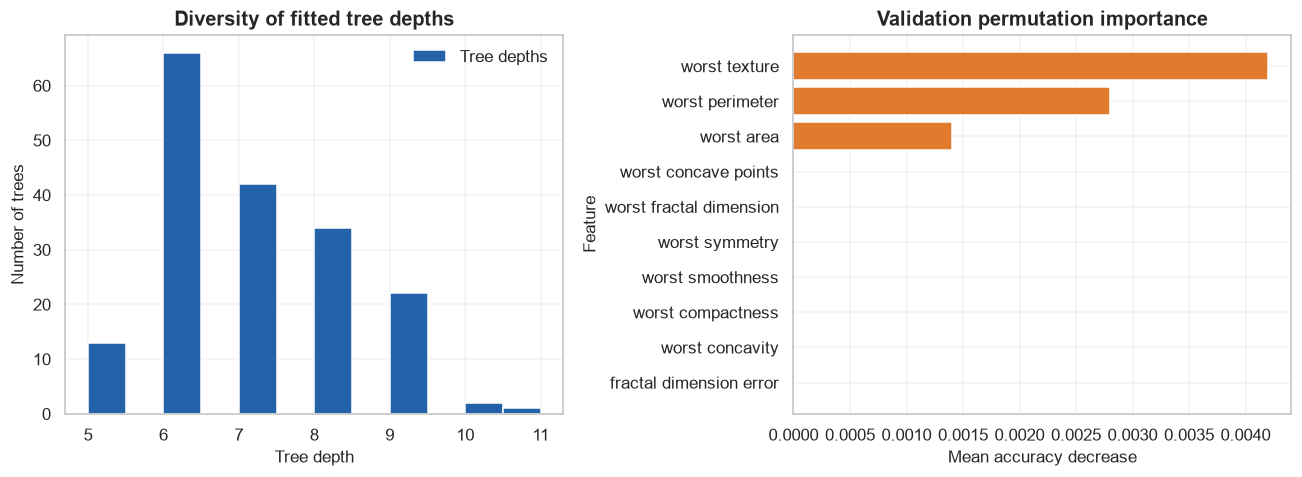

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

data=load_breast_cancer()
X=data.data; y=data.target
X_train,X_validation,y_train,y_validation=train_test_split(X,y,test_size=.25,stratify=y,random_state=RANDOM_SEED)
scratch=BaggedStumpsScratch(n_estimators=41).fit(X_train,y_train)
forest=RandomForestClassifier(n_estimators=180,max_features="sqrt",oob_score=True,random_state=RANDOM_SEED).fit(X_train,y_train)
print("Scratch forest/library accuracy:",round(accuracy_score(y_validation,scratch.predict(X_validation)),3),round(forest.score(X_validation,y_validation),3))
print("OOB score:",round(forest.oob_score_,3),"trees:",len(forest.estimators_))
importance=permutation_importance(forest,X_validation,y_validation,n_repeats=5,random_state=RANDOM_SEED)
top=np.argsort(importance.importances_mean)[-10:]
figure,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].hist([estimator.tree_.max_depth for estimator in forest.estimators_],bins=12,color=COURSE_COLORS["blue"],edgecolor="white",label="Tree depths"); axes[0].set(title="Diversity of fitted tree depths",xlabel="Tree depth",ylabel="Number of trees"); axes[0].legend()
axes[1].barh(np.array(data.feature_names)[top],importance.importances_mean[top],color=COURSE_COLORS["orange"]); axes[1].set(title="Validation permutation importance",xlabel="Mean accuracy decrease",ylabel="Feature")
figure.tight_layout(); plt.show()

**How to interpret the result:** Bootstrap and feature randomness produce diverse depths. Permutation importance measures validation-score sensitivity, not causation.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Additional trees stabilize the Monte Carlo average but eventually give diminishing returns and cost more compute.

,trees,validation_accuracy
0,1,0.923
1,5,0.937
2,15,0.958
3,40,0.951
4,100,0.958
5,180,0.958


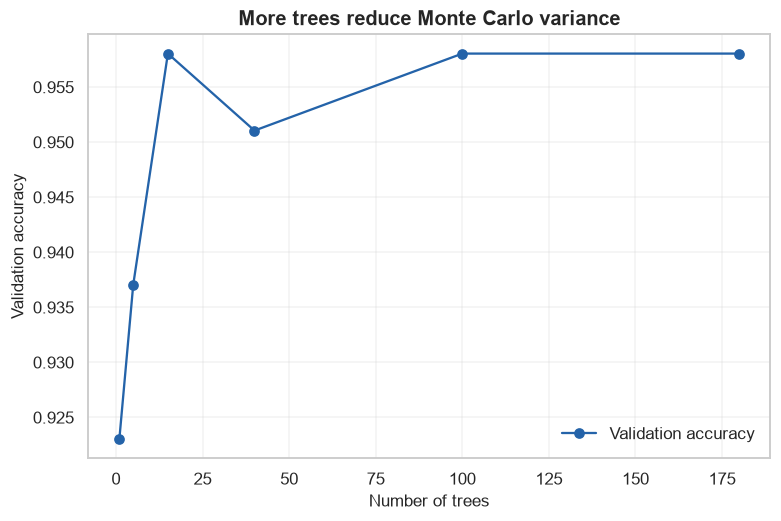

In [4]:
counts=[1,5,15,40,100,180]; rows=[]
for count in counts:
    candidate=RandomForestClassifier(n_estimators=count,max_features="sqrt",random_state=RANDOM_SEED).fit(X_train,y_train)
    rows.append({"trees":count,"validation_accuracy":candidate.score(X_validation,y_validation)})
forest_results=pd.DataFrame(rows); display(forest_results.round(3))
figure,axis=plt.subplots(); axis.plot(forest_results["trees"],forest_results["validation_accuracy"],marker="o",color=COURSE_COLORS["blue"],label="Validation accuracy")
axis.set(title="More trees reduce Monte Carlo variance",xlabel="Number of trees",ylabel="Validation accuracy"); axis.legend(); plt.show()

## 18. Common mistakes

            - Fitting preprocessing before splitting
- Selecting hyperparameters on test data
- Reporting one metric without a baseline
- Confusing predictive association with causation

            ## 19. Advantages and disadvantages

            **Advantages**

            - Direct objective from labeled examples
- Clear held-out evaluation

            **Disadvantages**

            - Less interpretable than one tree
- Larger memory and prediction cost
- Impurity importance can be biased

            ## 20. When to use and when not to use the algorithm

            **Use it when:** a trustworthy target represents the decision and representative labeled examples are available.

            **Do not use it when:** labels do not represent the desired outcome or the goal is causal intervention rather than prediction.

## 21. Exercises

1. **Conceptual:** Why must the test set remain untouched during selection?
2. **Mathematical/hand calculation:** Calculate the displayed equation on a small example.
3. **Coding/experimentation:** Change one hyperparameter and explain training-versus-validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Repeated test feedback leaks selection information and makes final performance optimistic.
2. Substitute each number, compute in the displayed order, and retain units.
3. Keep the split fixed, retrain each candidate, and prefer stable validation evidence rather than the best training score.

</details>

## 23. Summary and key takeaways

            - Data splitting and preprocessing are part of the model
- Scratch code explains the mechanism while the library version supports realistic use
- Metrics must match error costs
- Generalization—not memorization—is the objective

            ## 24. Further reading

            - [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)